In [1]:
# Análisis Exploratorio de Datos (EDA)
## Previsión de Demanda - PYMES de Alimentos Preparados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar datos
df = pd.read_excel('../data/raw/dataset_sintetico_demanda_lima.xlsx')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 730 filas, 12 columnas


,fecha,dia_semana,es_festivo,mes,temperatura_promedio,precipitacion_mm,demanda_real,demanda_pronosticada,desperdicio_sin_modelo,desperdicio_con_modelo,ahorro_economico_diario,co2_evitable_diario_kg
0,2023-01-01,Sunday,0,1,20.577809,1.011615,253,306,53,45,148.0,10.08
1,2023-01-02,Monday,1,1,17.316062,1.185527,241,218,0,32,-592.0,-40.32
2,2023-01-03,Tuesday,0,1,20.159099,1.835555,149,164,15,24,-166.5,-11.34
3,2023-01-04,Wednesday,0,1,27.301603,1.450017,186,168,0,25,-462.5,-31.50
4,2023-01-05,Thursday,0,1,22.484499,5.036314,149,150,1,22,-388.5,-26.46


In [3]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   fecha                    730 non-null    datetime64[us]
 1   dia_semana               730 non-null    str           
 2   es_festivo               730 non-null    int64         
 3   mes                      730 non-null    int64         
 4   temperatura_promedio     730 non-null    float64       
 5   precipitacion_mm         730 non-null    float64       
 6   demanda_real             730 non-null    int64         
 7   demanda_pronosticada     730 non-null    int64         
 8   desperdicio_sin_modelo   730 non-null    int64         
 9   desperdicio_con_modelo   730 non-null    int64         
 10  ahorro_economico_diario  730 non-null    float64       
 11  co2_evitable_diario_kg   730 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(6), str

In [4]:
# Estadísticas descriptivas
df.describe()

,fecha,es_festivo,mes,temperatura_promedio,precipitacion_mm,demanda_real,demanda_pronosticada,desperdicio_sin_modelo,desperdicio_con_modelo,ahorro_economico_diario,co2_evitable_diario_kg
count,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2023-12-31 12:00:00,0.076712,6.512329,19.353929,1.976258,201.147945,210.883562,14.086301,31.149315,-315.665753,-21.499397
min,2023-01-01 00:00:00,0.000000,1.000000,12.000000,0.003133,95.000000,103.000000,0.000000,15.000000,-906.500000,-61.740000
25%,2023-07-02 06:00:00,0.000000,4.000000,16.707835,0.589107,175.000000,180.000000,0.000000,27.000000,-499.500000,-34.020000
50%,2023-12-31 12:00:00,0.000000,7.000000,19.321838,1.418092,199.000000,208.000000,9.000000,31.000000,-370.000000,-25.200000
75%,2024-06-30 18:00:00,0.000000,9.750000,21.835368,2.777332,227.000000,239.000000,27.000000,35.000000,-129.500000,-8.820000
max,2024-12-30 00:00:00,1.000000,12.000000,28.000000,12.000000,340.000000,368.000000,57.000000,55.000000,166.500000,11.340000
std,NaN,0.266317,3.448303,3.853545,1.932724,36.259770,43.628484,15.293631,6.559710,229.012938,15.597638


In [5]:
# Verificar valores nulos
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print(f"Columnas con nulos: {len(nulls)}")
nulls

Columnas con nulos: 0


Series([], dtype: int64)

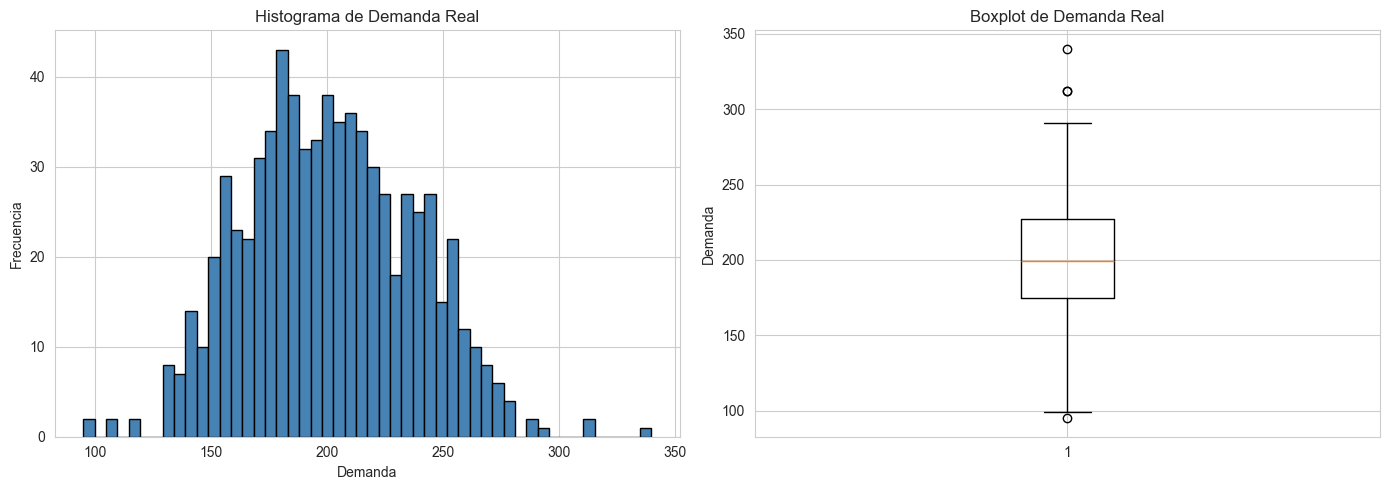

Media: 201.15
Mediana: 199.00
Desviación estándar: 36.26


In [6]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['demanda_real'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Histograma de Demanda Real')
axes[0].set_xlabel('Demanda')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['demanda_real'])
axes[1].set_title('Boxplot de Demanda Real')
axes[1].set_ylabel('Demanda')

plt.tight_layout()
plt.show()

print(f"Media: {df['demanda_real'].mean():.2f}")
print(f"Mediana: {df['demanda_real'].median():.2f}")
print(f"Desviación estándar: {df['demanda_real'].std():.2f}")

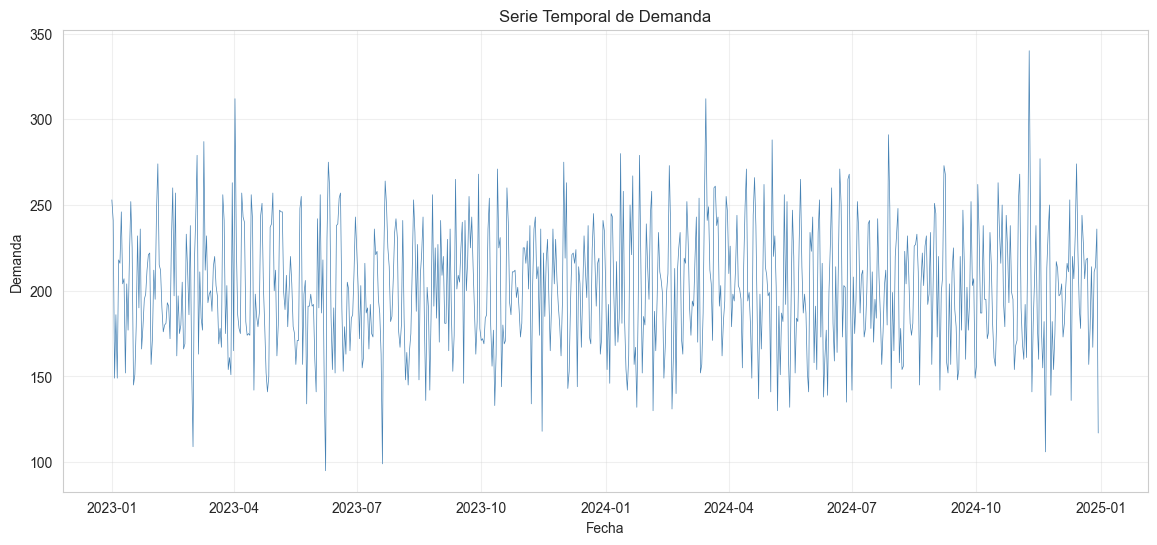

In [7]:
# Serie temporal completa
plt.figure(figsize=(14, 6))
plt.plot(df['fecha'], df['demanda_real'], color='steelblue', linewidth=0.5)
plt.title('Serie Temporal de Demanda')
plt.xlabel('Fecha')
plt.ylabel('Demanda')
plt.grid(True, alpha=0.3)
plt.show()

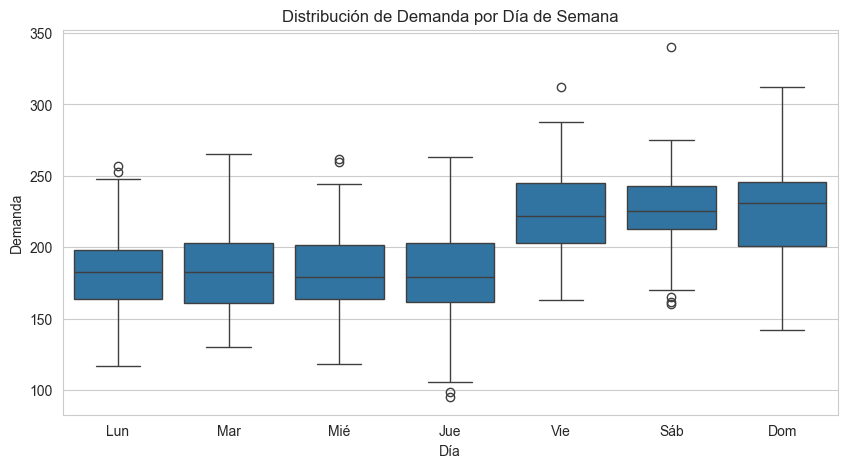

In [8]:
# Análisis de estacionalidad por día de semana
df['dia_semana'] = pd.to_datetime(df['fecha']).dt.dayofweek
dia_map = {0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'}
df['dia_nombre'] = df['dia_semana'].map(dia_map)

plt.figure(figsize=(10, 5))
sns.boxplot(x='dia_nombre', y='demanda_real', data=df, order=['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'])
plt.title('Distribución de Demanda por Día de Semana')
plt.xlabel('Día')
plt.ylabel('Demanda')
plt.show()

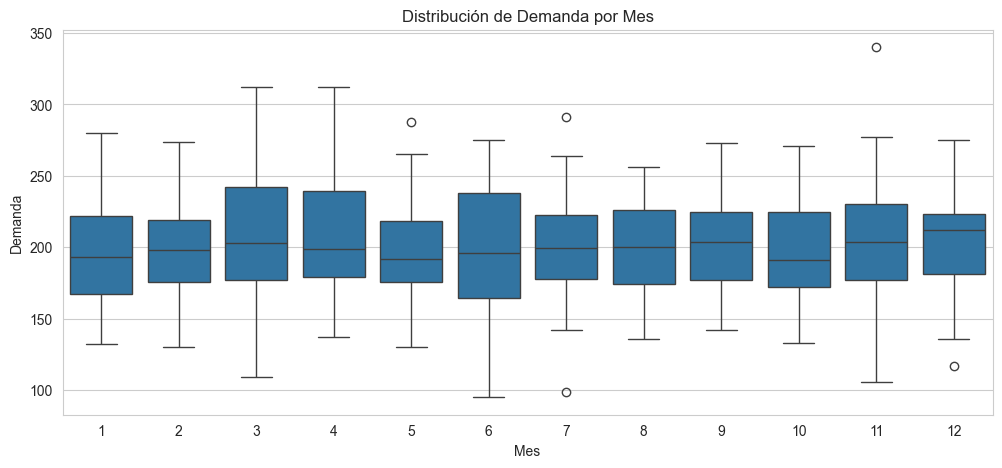

In [9]:
# Análisis de estacionalidad por mes
df['mes'] = pd.to_datetime(df['fecha']).dt.month

plt.figure(figsize=(12, 5))
sns.boxplot(x='mes', y='demanda_real', data=df)
plt.title('Distribución de Demanda por Mes')
plt.xlabel('Mes')
plt.ylabel('Demanda')
plt.show()

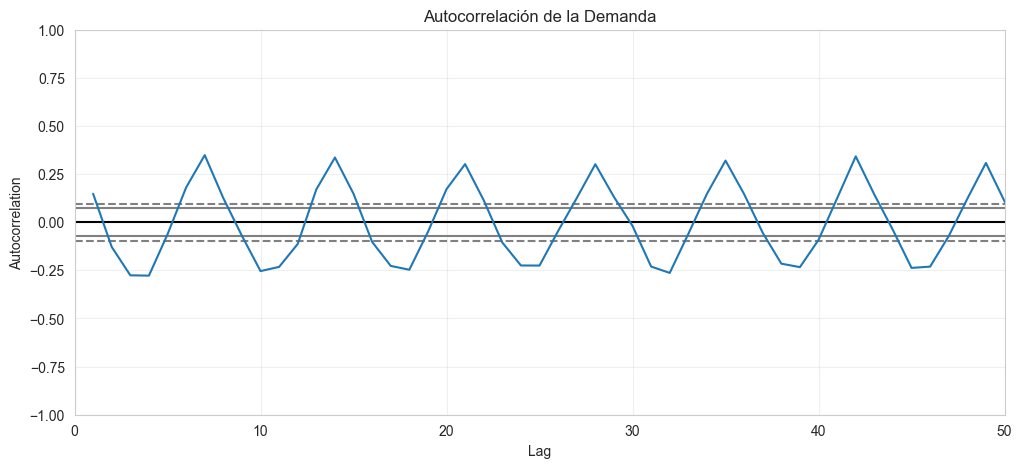

In [10]:
# Autocorrelación
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12, 5))
autocorrelation_plot(df['demanda_real'])
plt.title('Autocorrelación de la Demanda')
plt.xlim(0, 50)
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Outliers
Q1 = df['demanda_real'].quantile(0.25)
Q3 = df['demanda_real'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers = df[(df['demanda_real'] < lower) | (df['demanda_real'] > upper)]
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print(f"Rango normal: [{lower:.2f}, {upper:.2f}]")
    print(f"Valores fuera de rango: {outliers['demanda_real'].tolist()[:10]}")

Outliers detectados: 0 (0.00%)


In [12]:
# Resumen EDA
print("=" * 50)
print("RESUMEN DE ANÁLISIS EXPLORATORIO")
print("=" * 50)
print(f"Período: {df['fecha'].min()} a {df['fecha'].max()}")
print(f"Días totales: {len(df)}")
print(f"Demanda promedio: {df['demanda_real'].mean():.2f}")
print(f"Demanda máxima: {df['demanda_real'].max():.2f}")
print(f"Demanda mínima: {df['demanda_real'].min():.2f}")
print(f"Desviación estándar: {df['demanda_real'].std():.2f}")
print(f"Coeficiente de variación: {(df['demanda_real'].std()/df['demanda_real'].mean())*100:.2f}%")

RESUMEN DE ANÁLISIS EXPLORATORIO
Período: 2023-01-01 00:00:00 a 2024-12-30 00:00:00
Días totales: 730
Demanda promedio: 201.15
Demanda máxima: 340.00
Demanda mínima: 95.00
Desviación estándar: 36.26
Coeficiente de variación: 18.03%
